#### Project - `Flight Booking Price Prediction` 

#### Problem Statement:

The objective of this project is to analyze the flight booking dataset, as a thorough study of the data will aid in the discovery of valuable insights that will be enormous value to passengers. Apply EDA, statistical methods and Machine Learning algorithms in order to get meaningful information from it and Predict future Flight Booking Prices.

#### About the Dataset:
`Flight Booking price prediction` dataset contains around 3 lacs records with 11 attributes.

* **Link:** https://drive.google.com/file/d/1v_zxN-gshcRUbxgL0Oww6Yq4WdZuB4tz/view?usp=drive_link

#### 1. Import necessary libraries

In [1]:
# import necessary packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# import configurational libraries
import warnings
warnings.filterwarnings('ignore')

#### 2. Data Loading & Inspection

In [2]:
# load and understand data
flight_booking_df = pd.read_csv('D:\INTELLIPAAT LEARNINGS COM FILES\PYTHON\VS Code Python\dsenv\Flight_Booking.csv')

In [3]:
flight_booking_df

,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955
...,...,...,...,...,...,...,...,...,...,...,...,...
300148,300148,Vistara,UK-822,Chennai,Morning,one,Evening,Hyderabad,Business,10.08,49,69265
300149,300149,Vistara,UK-826,Chennai,Afternoon,one,Night,Hyderabad,Business,10.42,49,77105
300150,300150,Vistara,UK-832,Chennai,Early_Morning,one,Night,Hyderabad,Business,13.83,49,79099
300151,300151,Vistara,UK-828,Chennai,Early_Morning,one,Evening,Hyderabad,Business,10.00,49,81585


In [4]:
# TOP 10 ROWS
flight_booking_df.head(10)

,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955
5,5,Vistara,UK-945,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.33,1,5955
6,6,Vistara,UK-927,Delhi,Morning,zero,Morning,Mumbai,Economy,2.08,1,6060
7,7,Vistara,UK-951,Delhi,Afternoon,zero,Evening,Mumbai,Economy,2.17,1,6060
8,8,GO_FIRST,G8-334,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.17,1,5954
9,9,GO_FIRST,G8-336,Delhi,Afternoon,zero,Evening,Mumbai,Economy,2.25,1,5954


In [5]:
# Columns names
flight_booking_df.columns

Index(['Unnamed: 0', 'airline', 'flight', 'source_city', 'departure_time',
       'stops', 'arrival_time', 'destination_city', 'class', 'duration',
       'days_left', 'price'],
      dtype='object')

**Dataset Columns Explained:**
- `Airline`         :  Name of the Airline Company.
- `Flight`          :  Plane's flight code
- `Source City`     :  City from which the flight takes off.
- `Departure Time`  :  Time of Departure
- `Stops`           :  Number of stops between the source and destination cities
- `Arrival Time`    :  Time of Arrival
- `Destination City`:  City where the flight will land.
- `Class`           :  Contains information on seat class.
- `Duration`        :  Overall amount of time taken to travel between cities in hours.
- `Days left`       :  Subtracting the trip date by the booking data
- `Price`           :  Ticket Price.

In [6]:
# Types of Airlines
flight_booking_df['airline'].value_counts()

airline
Vistara      127859
Air_India     80892
Indigo        43120
GO_FIRST      23173
AirAsia       16098
SpiceJet       9011
Name: count, dtype: int64

In [7]:
# Basic Information of Dataset
flight_booking_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        300153 non-null  int64  
 1   airline           300153 non-null  object 
 2   flight            300153 non-null  object 
 3   source_city       300153 non-null  object 
 4   departure_time    300153 non-null  object 
 5   stops             300153 non-null  object 
 6   arrival_time      300153 non-null  object 
 7   destination_city  300153 non-null  object 
 8   class             300153 non-null  object 
 9   duration          300153 non-null  float64
 10  days_left         300153 non-null  int64  
 11  price             300153 non-null  int64  
dtypes: float64(1), int64(3), object(8)
memory usage: 27.5+ MB


In [8]:
# Checking DataType of each column
flight_booking_df.dtypes

Unnamed: 0            int64
airline              object
flight               object
source_city          object
departure_time       object
stops                object
arrival_time         object
destination_city     object
class                object
duration            float64
days_left             int64
price                 int64
dtype: object

In [9]:
# All Categorical Columns
flight_booking_df.select_dtypes(include = 'object')

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class
0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy
1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy
2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy
3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy
4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy
...,...,...,...,...,...,...,...,...
300148,Vistara,UK-822,Chennai,Morning,one,Evening,Hyderabad,Business
300149,Vistara,UK-826,Chennai,Afternoon,one,Night,Hyderabad,Business
300150,Vistara,UK-832,Chennai,Early_Morning,one,Night,Hyderabad,Business
300151,Vistara,UK-828,Chennai,Early_Morning,one,Evening,Hyderabad,Business


In [10]:
# Statistical Summary of Categorical & Numerical Columns
flight_booking_df.describe(include = 'all')

,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
count,300153.000000,300153,300153,300153,300153,300153,300153,300153,300153,300153.000000,300153.000000,300153.000000
unique,NaN,6,1561,6,6,3,6,6,2,NaN,NaN,NaN
top,NaN,Vistara,UK-706,Delhi,Morning,one,Night,Mumbai,Economy,NaN,NaN,NaN
freq,NaN,127859,3235,61343,71146,250863,91538,59097,206666,NaN,NaN,NaN
mean,150076.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.221021,26.004751,20889.660523
std,86646.852011,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.191997,13.561004,22697.767366
min,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.830000,1.000000,1105.000000
25%,75038.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.830000,15.000000,4783.000000
50%,150076.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.250000,26.000000,7425.000000
75%,225114.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16.170000,38.000000,42521.000000


**Observations :**

1. Dataset contains Flight & Airline Company Information, It contains flights information like airline names, flight names, departure time of flight, stops of the, source and destination city of flight, duration etc.

2. It contains 3 lack rows and 12 columns(Numeric - 4 & Categorical - 8 columns), well assigned datatypes.

3. It contains details of airlines : 
    - Vistara
    - Air_India
    - Indigo
    - GO_First
    - AirAsia
    - SpiceJet etc.

#### 3. Data Preprocessing & Cleaning

In [11]:
# drop the `Unnamed :0` column because it does not contribute anything to the model performance
flight_booking_df.drop(['Unnamed: 0'], axis = 1, inplace = True)

In [12]:
flight_booking_df

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955
...,...,...,...,...,...,...,...,...,...,...,...
300148,Vistara,UK-822,Chennai,Morning,one,Evening,Hyderabad,Business,10.08,49,69265
300149,Vistara,UK-826,Chennai,Afternoon,one,Night,Hyderabad,Business,10.42,49,77105
300150,Vistara,UK-832,Chennai,Early_Morning,one,Night,Hyderabad,Business,13.83,49,79099
300151,Vistara,UK-828,Chennai,Early_Morning,one,Evening,Hyderabad,Business,10.00,49,81585


In [13]:
# how many types of airline companies are there 
flight_booking_df['airline'].value_counts().count()

np.int64(6)

In [14]:
# How many types of classes are there in flights
flight_booking_df['class'].value_counts().index

Index(['Economy', 'Business'], dtype='object', name='class')

In [15]:
# null check
flight_booking_df.isnull().sum()

airline             0
flight              0
source_city         0
departure_time      0
stops               0
arrival_time        0
destination_city    0
class               0
duration            0
days_left           0
price               0
dtype: int64

In [16]:
# duplicate check
flight_booking_df.duplicated().sum()

np.int64(0)

**Observation :**

1. It contains 6 types of Airlines and 2 Types of Classes (Business & Economy).

2. It contains no missing values and 1 duplicate values.

#### 4. Data Visualization

**Visualizing the `Variation of price with different airlines`**

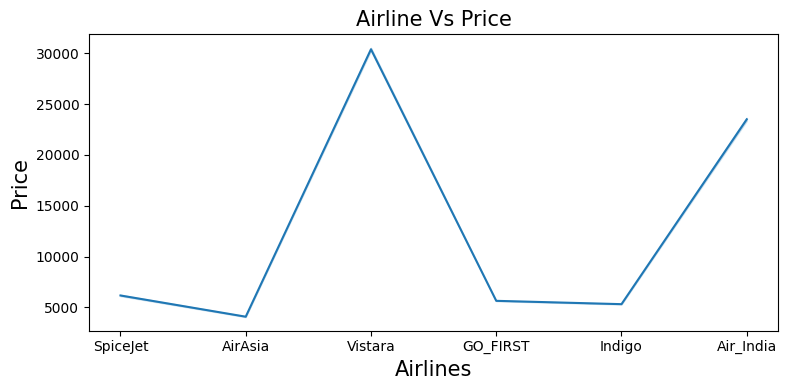

In [17]:
plt.figure(figsize = (8, 4))

sns.lineplot(x = flight_booking_df['airline'], y = flight_booking_df['price'])

plt.xlabel('Airlines', fontsize = 15)
plt.ylabel('Price', fontsize = 15)
plt.title('Airline Vs Price', fontsize = 15)

plt.tight_layout()
plt.show()

**Insights:**
- Vistara and Air_India flight tickets are very expensive when compared to other airline companies.
- Vistara Airline company flight ticket price is some where between 29000 to 30000, and Air India Flight ticket price is between 23000 to 25000.

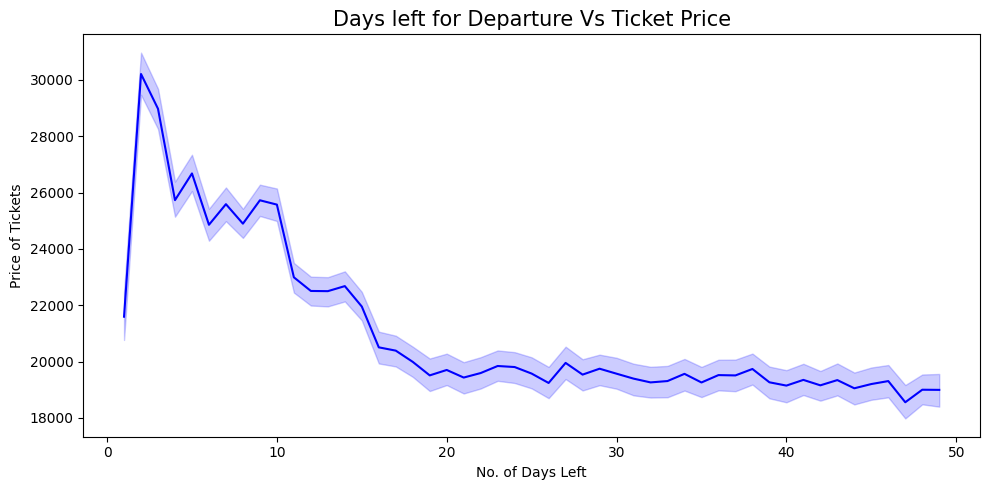

In [18]:
# line plot between days left and price to know the price increase or decrease as departure comes close.
plt.figure(figsize = (10, 5))

sns.lineplot(x = flight_booking_df['days_left'], y = flight_booking_df['price'], color = 'blue')

plt.title('Days left for Departure Vs Ticket Price', fontsize = 15)
plt.xlabel('No. of Days Left')
plt.ylabel('Price of Tickets')

plt.tight_layout()
plt.show()

**Observation :**
- From Days 2 to 3, the price of the ticket is increased and from 4th day the price of the ticket is seen to be gradually decreasing, so it is clear that as the departure time comes close the price of the ticket decreases gradually.

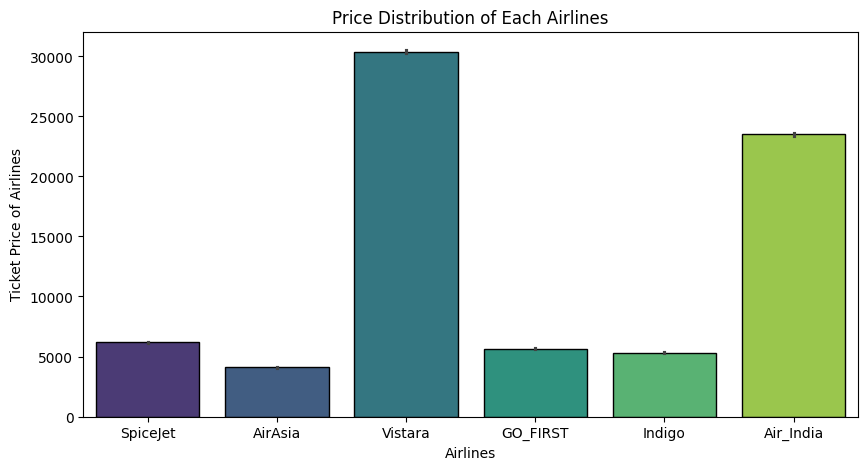

In [19]:
# Price range of all flights
plt.figure(figsize = (10, 5))
sns.barplot(x = 'airline', y = 'price', palette = 'viridis', edgecolor = 'k', data = flight_booking_df)

plt.xlabel("Airlines")
plt.ylabel("Ticket Price of Airlines")
plt.title("Price Distribution of Each Airlines")

plt.show()

**Insights:**
- 'Vistara' and 'Air_India' Companies Flight tickets are very expensive compared to others Airlines(Spicejet, AirAsia, GO_First, Indigo, Air_India).

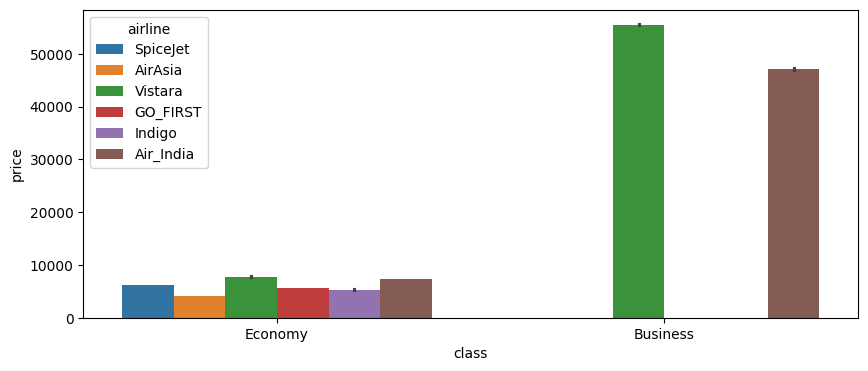

In [20]:
# range of price of all the flights of economy and business class.
plt.figure(figsize = (10, 4))

sns.barplot(x = 'class',y = 'price', data = flight_booking_df, hue = 'airline')
plt.show()

**Insights:**
- Price of 'Economy' class Flight tickets is very low as Business class flight tickets of Vistara airline and Air_india airline is quite expensive.

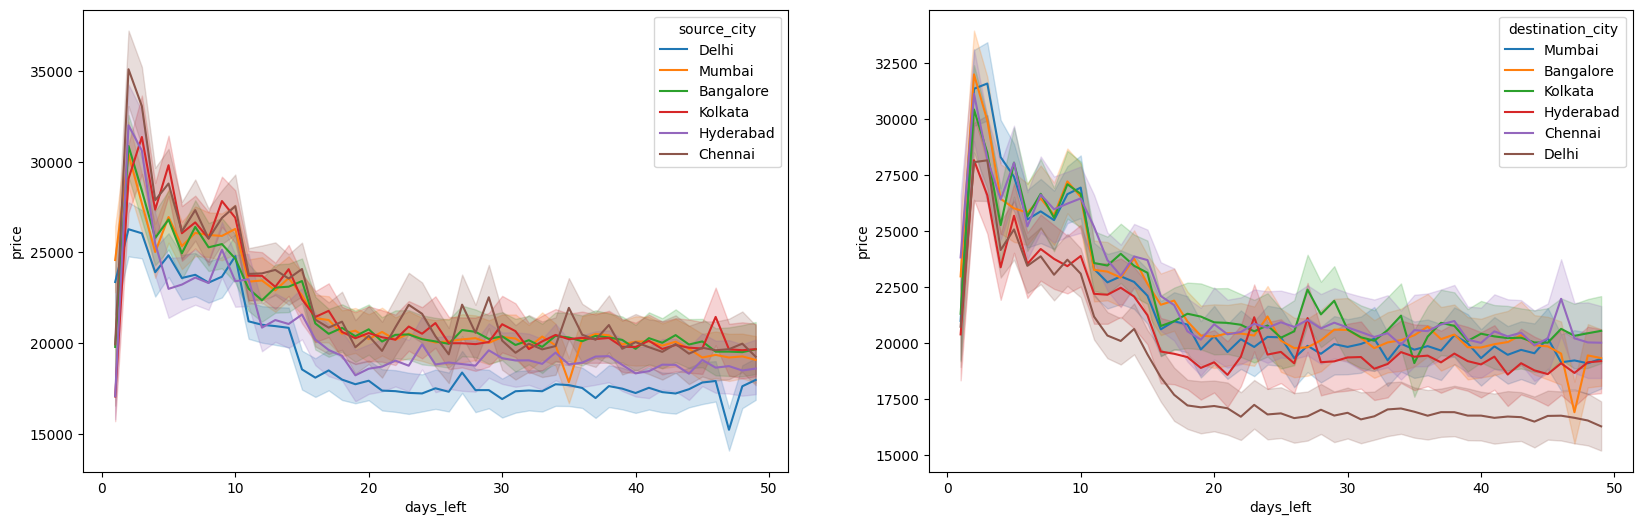

In [21]:
# Range of price of flights with source and destination city according to the days left
fig, ax = plt.subplots(1, 2, figsize = (20, 6))

sns.lineplot(ax = ax[0], x = 'days_left', y = 'price', data = flight_booking_df, hue = 'source_city')
sns.lineplot(ax = ax[1], x = 'days_left', y = 'price', data = flight_booking_df, hue = 'destination_city')
plt.show()

**Observations :**

1. As the days left decreases(departure time comes close) the price range of flights with source and destination are decreasing gradually.

2. Price of Flight Tickets having source city as Delhi and Hyderabad and Destination city as "Delhi" and "Hyderabad" gradually decrease as the departure time comes close.

**Visualization of Categorical features with countplot.**

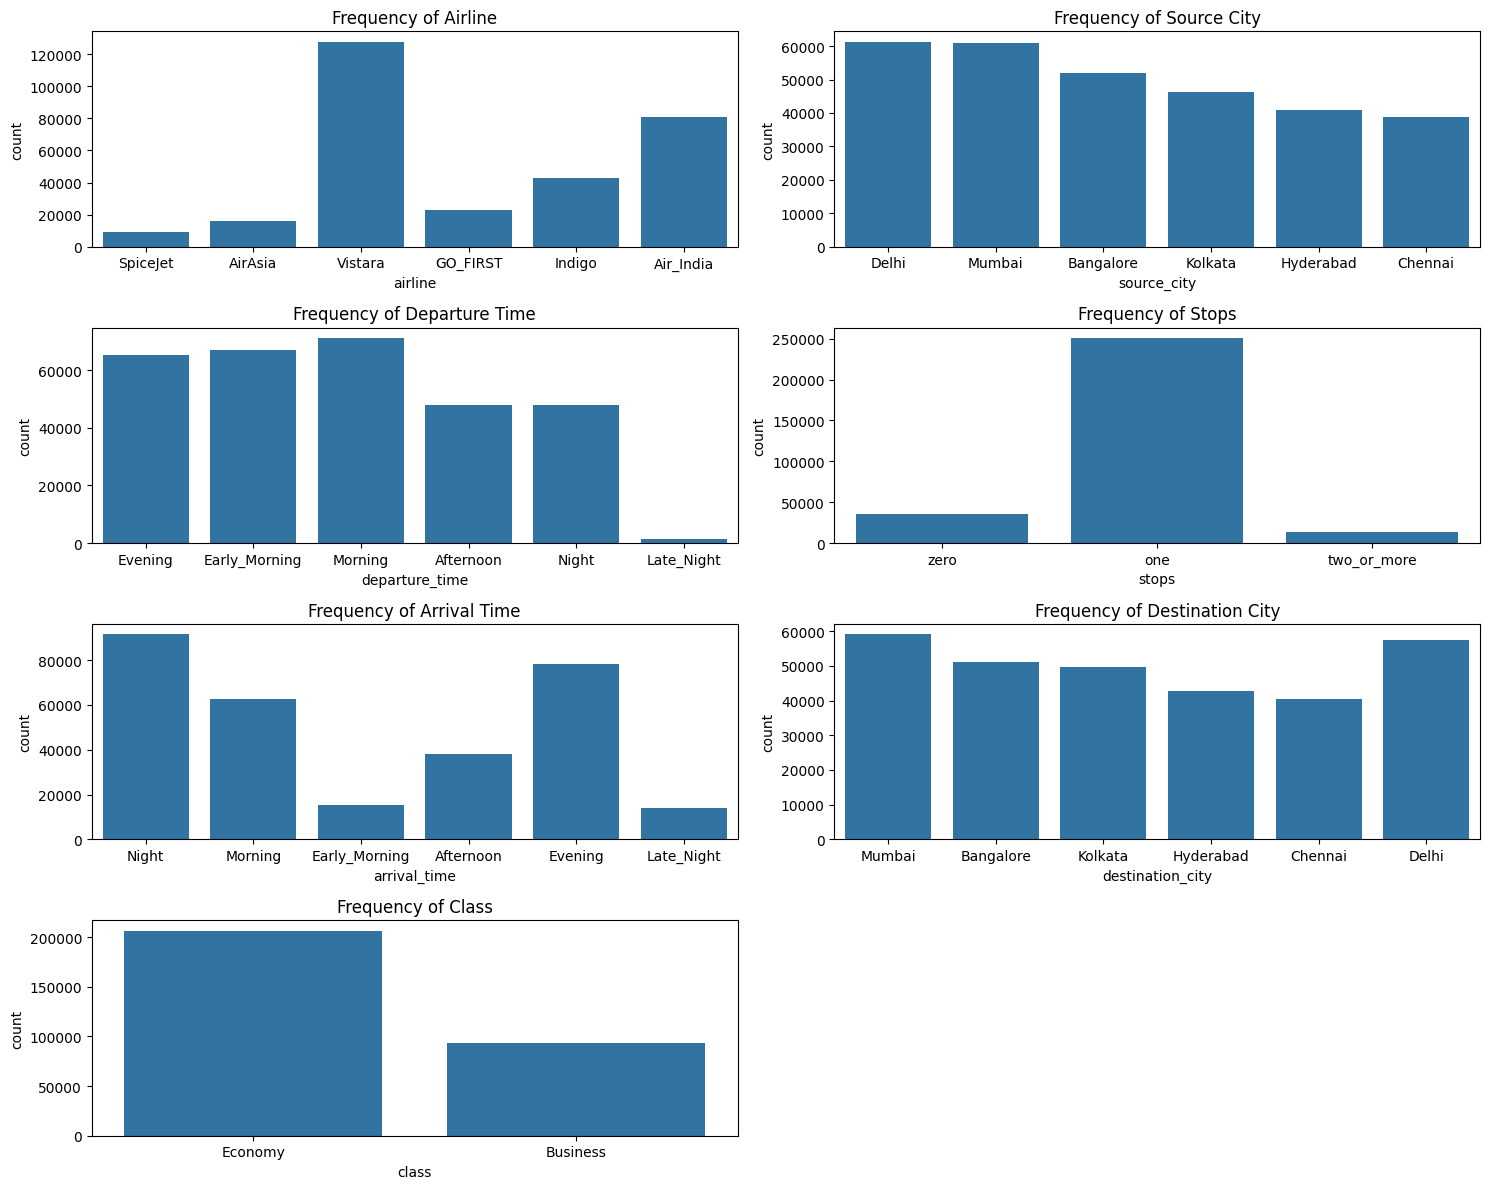

In [22]:
plt.figure(figsize = (15, 12))

# 
plt.subplot(4, 2, 1)
sns.countplot(x = 'airline', data = flight_booking_df)
plt.title('Frequency of Airline')

plt.subplot(4, 2, 2)
sns.countplot(x = 'source_city', data = flight_booking_df)
plt.title('Frequency of Source City')

plt.subplot(4, 2, 3)
sns.countplot(x = 'departure_time', data = flight_booking_df)
plt.title('Frequency of Departure Time')

plt.subplot(4, 2, 4)
sns.countplot(x = 'stops', data = flight_booking_df)
plt.title('Frequency of Stops')

plt.subplot(4, 2, 5)
sns.countplot(x = 'arrival_time', data = flight_booking_df)
plt.title('Frequency of Arrival Time')

plt.subplot(4, 2, 6)
sns.countplot(x = 'destination_city', data = flight_booking_df)
plt.title('Frequency of Destination City')

plt.subplot(4, 2, 7)
sns.countplot(x = 'class', data = flight_booking_df)
plt.title('Frequency of Class')

plt.tight_layout()
plt.show()

**Observations :**

* From the Above Bar Charts we can say that :
    - Passenger Travel Mostly from Vistara and Air India
    - Most of the Airlines stop only once.
    - Most of the Flights Arrive at Morning, Evening or Night.
    - Passengers book flight tickets to reach destination city Mumbai and Delhi.
    - Tickets booked for Economy Class are more compared to Business Class.
    

#### 5. Label Encoding

Converting Categorical Columns into Numerical Columns Using Label Encoding Technique.

In [23]:
# Encoding categorical values to numerical values
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

df = flight_booking_df

df['airline'] = le.fit_transform(df['airline'])
df['source_city'] = le.fit_transform(df['source_city'])
df['departure_time'] = le.fit_transform(df['departure_time'])
df['stops'] = le.fit_transform(df['stops'])
df['arrival_time'] = le.fit_transform(df['arrival_time'])
df['destination_city'] = le.fit_transform(df['destination_city'])
df['class'] = le.fit_transform(df['class'])

In [24]:
df.head()

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,4,SG-8709,2,2,2,5,5,1,2.17,1,5953
1,4,SG-8157,2,1,2,4,5,1,2.33,1,5953
2,0,I5-764,2,1,2,1,5,1,2.17,1,5956
3,5,UK-995,2,4,2,0,5,1,2.25,1,5955
4,5,UK-963,2,4,2,4,5,1,2.33,1,5955


In [25]:
df['airline'].value_counts()

airline
5    127859
1     80892
3     43120
2     23173
0     16098
4      9011
Name: count, dtype: int64

**Note :**

- class 1 refers to "Economy" and 0 refers to "Business".

#### 6. Feature selection

**Note:**

- First we will be doing correlation analysis, to see which features are having strong correlation with the target variable and between features.
- Then we will do VIF-Variance Inflation Factore which is also a feature selection technique which let's us select the best features to use for model building

In [26]:
# Drop `Flight` column
df.drop('flight', axis = 1, inplace = True)

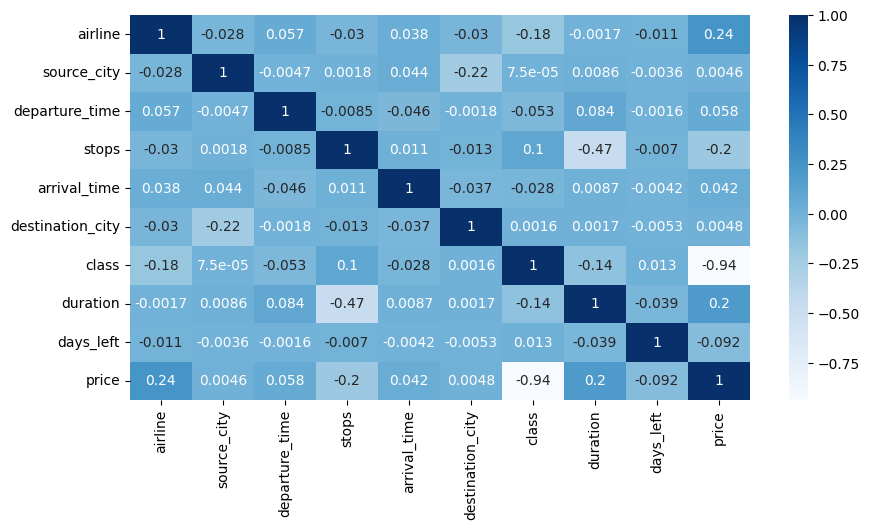

In [27]:
# Correlation Analysis
plt.figure(figsize = (10, 5))
sns.heatmap(df.corr(), annot = True, cmap = 'Blues')
plt.show()

**Insights:**
- No feature is having very strong correlation with Price [Target Variable].
- Duration has negative correlation ~-0.94 with Stops, class has negative correlation ~0.94 with price column.

#### Feature selection using VIF - Variance Inflation factor.

In [28]:
# Import Variance Inflation Factor from STATSMODELS
from statsmodels.stats.outliers_influence import variance_inflation_factor as vif

# Empty Columns List
cols_list = []

# Grab all Numerical Columns (Int & Float)
for col in df.columns:
    if((df[col].dtype != 'object') & (col != 'price')):
        cols_list.append(col)

**Iteration - 1**

In [29]:
X = df[cols_list]
vif_data = pd.DataFrame()
vif_data['Features'] = X.columns
vif_data['VIF'] = [vif(X.values, i) for i in range(len(X.columns))]
print(vif_data)

           Features       VIF
0           airline  3.393124
1       source_city  2.927766
2    departure_time  2.779427
3             stops  1.426614
4      arrival_time  3.684550
5  destination_city  2.885337
6             class  2.849370
7          duration  4.113876
8         days_left  3.976790


**Note :**

1. VIF Value > 5 indicates multicollinearity issues, but here all columns have VIF Values below 5. So, we will move forward towards Feature Scaling.

#### 7. Feature Scaling

As, we see out data has columns with very large alues and also columns with small values, we need to bring the columns values at same scale using Standardization Scaling Technique.

In [30]:
X = df.drop(columns = ['price']) # independant variable
y = df['price'] # dependent variables

In [31]:
# Import necessary packages
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression 
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error

In [32]:
# Divide the data into train and test sets into 80:20 ratio, 80% of data for training purpose and 20% of data for testing purpose.
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [33]:
# standardizing the x_train and x_test data
sc = StandardScaler()
x_train_scaled = sc.fit_transform(x_train)
x_test_scaled = sc.fit_transform(x_test)

In [34]:
# Standardized x train data
x_train_scaled

array([[-1.15009744,  0.81160707, -1.37873905, ...,  0.67246146,
         1.00173042, -1.47488258],
       [-0.05891224, -0.33003243, -1.37873905, ...,  0.67246146,
        -0.72463441, -0.95897275],
       [-1.15009744,  0.81160707, -1.37873905, ..., -1.48707407,
         1.24497828,  1.32577077],
       ...,
       [-1.15009744,  0.81160707,  1.47332728, ...,  0.67246146,
         0.20248744,  0.22024971],
       [-0.60450484,  0.81160707, -1.37873905, ...,  0.67246146,
        -0.53976604,  0.95726375],
       [-1.15009744,  0.81160707, -1.37873905, ...,  0.67246146,
         1.1059795 , -0.66416714]], shape=(240122, 9))

In [35]:
x_test_scaled

array([[-1.14043916, -0.32847651,  0.89923663, ...,  0.6730321 ,
         1.04389284,  1.03627312],
       [ 1.03966157,  0.81351534,  0.89923663, ..., -1.48581322,
        -0.33722198,  1.18407332],
       [ 1.03966157,  0.81351534,  0.89923663, ...,  0.6730321 ,
        -0.24394104,  1.11017322],
       ...,
       [-1.14043916,  0.24251942, -0.8063761 , ...,  0.6730321 ,
         0.18487284,  0.14947194],
       [-0.0503888 ,  0.24251942, -0.23783852, ...,  0.6730321 ,
        -1.42735596,  1.03627312],
       [ 1.03966157, -0.89947243,  1.46777421, ..., -1.48581322,
         1.83330021, -1.69803053]], shape=(60031, 9))

In [37]:
# Convert Scaled data back to dataframe format 
x_train = pd.DataFrame(x_train_scaled, columns = x_train.columns)
x_test = pd.DataFrame(x_test_scaled, columns = x_test.columns)

In [38]:
x_train

,airline,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left
0,-1.150097,0.811607,-1.378739,-0.427555,0.530207,-0.908976,0.672461,1.001730,-1.474883
1,-0.058912,-0.330032,-1.378739,1.072545,1.104303,-0.908976,0.672461,-0.724634,-0.958973
2,-1.150097,0.811607,-1.378739,-0.427555,-1.766177,-0.908976,-1.487074,1.244978,1.325771
3,1.032273,0.240787,1.473327,-0.427555,-1.192081,-1.481781,0.672461,-0.272888,-1.106376
4,1.032273,0.811607,1.473327,-0.427555,1.104303,-0.908976,-1.487074,1.985842,-1.548584
...,...,...,...,...,...,...,...,...,...
240117,1.032273,0.811607,-0.237913,-0.427555,-1.766177,-0.336171,0.672461,1.151849,-1.769688
240118,1.032273,-1.471672,1.473327,-0.427555,1.104303,-0.908976,-1.487074,1.835723,-1.401181
240119,-1.150097,0.811607,1.473327,-0.427555,0.530207,1.382244,0.672461,0.202487,0.220250
240120,-0.604505,0.811607,-1.378739,-0.427555,1.104303,0.236634,0.672461,-0.539766,0.957264


In [39]:
x_test

,airline,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left
0,-1.140439,-0.328477,0.899237,-0.423737,-1.186018,0.808291,0.673032,1.043893,1.036273
1,1.039662,0.813515,0.899237,-0.423737,1.111762,1.383169,-1.485813,-0.337222,1.184073
2,1.039662,0.813515,0.899237,-0.423737,1.111762,-1.491219,0.673032,-0.243941,1.110173
3,1.039662,-0.899472,1.467774,-0.423737,0.537317,-0.341464,-1.485813,0.312960,-0.885129
4,-1.140439,-1.470468,-1.374914,-0.423737,1.111762,1.383169,0.673032,-0.557198,-0.441729
...,...,...,...,...,...,...,...,...,...
60026,-1.140439,-0.328477,-0.806376,-0.423737,-0.611573,1.383169,0.673032,0.045648,0.075572
60027,-0.050389,-0.328477,-0.237839,2.594638,1.111762,1.383169,0.673032,-1.403688,0.223372
60028,-1.140439,0.242519,-0.806376,-0.423737,1.111762,-1.491219,0.673032,0.184873,0.149472
60029,-0.050389,0.242519,-0.237839,2.594638,-0.611573,0.808291,0.673032,-1.427356,1.036273


In [40]:
# Shape of X train and x test
print("Shape of X Train :", x_train.shape)
print("Shape of X Test", x_test.shape)

Shape of X Train : (240122, 9)
Shape of X Test (60031, 9)


**Note :**

We have 2 lack 40,122 rows & 9 Columns for Training and 60,031 rows and 9 columns for Testing Model.

In [41]:
# Build Linear Regression Model
lr = LinearRegression()

# Train the model
lr.fit(x_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [42]:
# Make predictions using x test data
y_pred = lr.predict(x_test)

# Display the predictions
y_pred

array([ 4572.47722217, 52809.22690738,  7857.62664973, ...,
        5837.95660509, -1555.5112795 , 58744.17576176], shape=(60031,))

In [43]:
# Display the Actual data and predictions made by model in one dataframe named `Difference`
difference = pd.DataFrame(np.c_[y_test, y_pred], columns = ['Actual', 'Predicted Value'])
difference

,Actual,Predicted Value
0,7366.0,4572.477222
1,64831.0,52809.226907
2,6195.0,7857.626650
3,60160.0,56096.253996
4,6578.0,6656.438105
...,...,...
60026,5026.0,5820.248216
60027,3001.0,486.438325
60028,6734.0,5837.956605
60029,5082.0,-1555.511279


#### 8. Model Evaluation

In [44]:
from sklearn.metrics import *

In [45]:
r2_score(y_test, y_pred)

0.9045526175497736

In [46]:
mae = mean_absolute_error(y_test, y_pred)
mae

4627.355215760444

In [47]:
mean_absolute_percentage_error(y_test, y_pred)

0.43614483147135974

In [48]:
mse = mean_squared_error(y_test, y_pred)
mse

49201433.71164045

In [49]:
rmse = np.sqrt(mse)
rmse

np.float64(7014.373365571614)

#### 9. Distribution of Actual values and Predicted Values

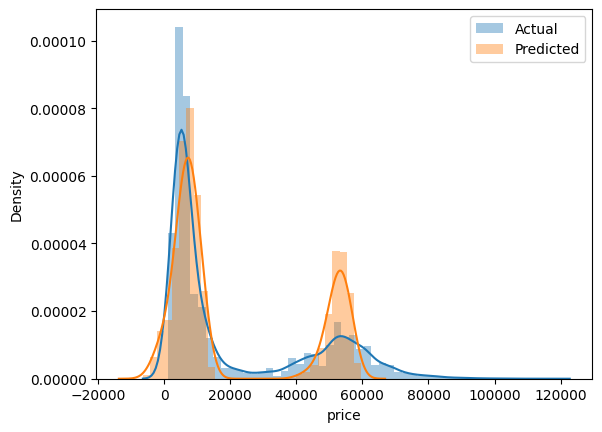

In [50]:
sns.distplot(y_test, label = 'Actual')
sns.distplot(y_pred, label = 'Predicted')
plt.legend()

**Observation :**

1. Seeing the Distribution plot of test data and predicted values, we can say that the predicted values are quite close to actual test data, which indicates accurate predictions of linear regression Model

#### 10. Decision Tree Regressor

In [51]:
# import necesary packages
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_percentage_error as mape

In [52]:
# build decision tree model
dt = DecisionTreeRegressor()

# Train DT Model
dt.fit(x_train, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [53]:
# make predictions on the model
y_pred = dt.predict(x_test)
y_pred

array([ 7366., 64831.,  6195., ...,  6734.,  5082., 70049.],
      shape=(60031,))

In [55]:
# Calculate r2_score of the model
print(f"R2 Score: {r2_score(y_test, y_pred)}")

R2 Score: 0.9721271646031459


In [56]:
# Calculate Mean Absolute Error made by the model
print(f"Mean Absolute Error: {mean_absolute_error(y_test, y_pred)}")

Mean Absolute Error: 1310.8883132603712


In [57]:
# Calculate Mean Absolute percentage error of the model
print(f"Mean Absolute Percentage Error: {mape(y_test, y_pred) * 100}")

Mean Absolute Percentage Error: 8.497185159113348


In [58]:
# Calculate Mean Squared error
print(f"Mean Squared Error: {mean_squared_error(y_test, y_pred)}")

Mean Squared Error: 14367952.561181353


In [59]:
# Calculate Root-Mean Squared Error
mse = mean_squared_error(y_test, y_pred)
print(f"Root mean squared error: {np.sqrt(mse)}")

Root mean squared error: 3790.5082193792105


#### 11. Random Forest Regressor

In [60]:
# import necessary packages
from sklearn.ensemble import RandomForestRegressor

In [61]:
rfr = RandomForestRegressor()

In [62]:
rfr.fit(x_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [63]:
y_pred = rfr.predict(x_test)
y_pred

array([ 6784.59, 67423.69,  6195.  , ...,  6716.25,  4157.56, 70485.59],
      shape=(60031,))

In [64]:
# calculate r2_score of random forest model
print(f"R2 Score: {r2_score(y_test, y_pred)}")

R2 Score: 0.9826894514353572


In [65]:
# mean abolute error
print(f"Mean absolute error: {mean_absolute_error(y_test, y_pred)}")

Mean absolute error: 1194.7494078595764


In [66]:
# Mean absolute percentage error
print(f"Mean absolute percentage error: {mape(y_test, y_pred) * 100}")

Mean absolute percentage error: 7.815505243244603


In [67]:
# mean squared error
print(f"Mean Squared Error: {mean_squared_error(y_test, y_pred)}")

Mean Squared Error: 8923280.93082645


In [68]:
# root mean squared error
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
print(f"RMSE: {rmse}")

RMSE: 2987.1861225619086


#### 12. Distribution of Actual values and predicted values of RF Model

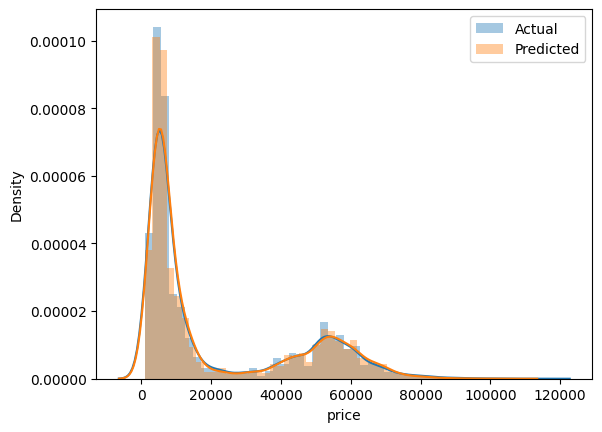

In [69]:
sns.distplot(y_test, label = 'Actual')
sns.distplot(y_pred, label = 'Predicted')
plt.legend()

**Observations :**

Seeing the distribution plot of predicted values by random forest regressor model and test data we can say that the predicted values are quite close to test data, which indicates the Random Forest is performing well when it comes to accurate predictions compared to Linear Regression and Decision Tree Regressor Algorithms.

**Findings / Insights :**

**1. Airline Price Comparison Insight :**

- From the airline-wise price distribution analysis, I observed that Vistara and Air India flights have significantly higher ticket prices compared to other airlines such as Indigo, SpiceJet, AirAsia, and GO First.

- The average ticket price for Vistara was around ~29,000 – ~30,000, while Air India ranged between ~23,000 – ~25,000.This indicates that these airlines may offer premium services or business-class options, which increases the overall ticket price.

**2. Departure Time vs Ticket Price Insight :**

- From the analysis of days left before departure vs ticket price, I observed a trend where ticket prices tend to decrease as the departure date approaches in this dataset.

- This suggests that airlines may reduce ticket prices closer to departure time in order to fill remaining seats and maximize occupancy.


**3. Economy vs Business Class Insight :**

- The analysis of ticket class vs price showed that Business class tickets are significantly more expensive than Economy class tickets.

- This price difference is especially noticeable in Vistara and Air India flights, where business-class fares are much higher due to premium seating, additional services, and enhanced travel comfort.


**4. Passenger Travel Pattern Insight :**

- The dataset analysis also revealed travel behavior patterns among passengers. Most flights were operated by Vistara and Air India, indicating high passenger demand for these airlines. Additionally, flights were observed to arrive mostly during morning, evening, or night time slots, suggesting that airlines schedule arrivals during peak travel hours.

- The most frequent destination cities were Mumbai and Delhi, indicating these cities act as major travel hubs.
Furthermore, the majority of passengers booked Economy class tickets rather than Business class, showing that most travelers prefer cost-effective travel options.

**Business Insights :**
*1. Premium airlines tend to charge higher fares due to better services and premium seating options.*
*2. Airlines may lower prices to avoid empty seats.*
*3. Seat class is a major driver of ticket price variation.*

**Model Evaluation Summary** : *To determine the best-performing model, three regression algorithms were evaluated: Linear Regression, Decision Tree Regressor, and Random Forest Regressor. Model performance was measured using R2 Score, Mean Absolute Error (MAE), Mean Absolute Percentage Error (MAPE), Mean Squared Error (MSE), and Root Mean Squared Error (RMSE).*

**1. Linear Regression :**

- The Linear Regression model achieved an **R2 score of 0.90**, indicating that it explains about 90% of the variance in the target variable. However, the error metrics such as **MAE (4627)** and **RMSE (7014)** are relatively higher compared to the other models.

- The distribution plot of predicted values and actual test data shows that predictions follow a similar pattern to the real data, but there are noticeable deviations. This suggests that while the model captures the general trend, it struggles to achieve highly precise predictions.

**2. Decision Tree Regressor :**

- The Decision Tree Regressor significantly improved performance with an **R2 score of 0.97**, meaning it explains 97% of the variance in the data. Additionally, the error values such as **MAE (1310)** and **RMSE (3790)** are much lower than those of the Linear Regression model.

- This indicates that the Decision Tree model captures non-linear relationships in the dataset more effectively, leading to more accurate predictions.

**3. Random Forest Regressor :**

- Among all models, the Random Forest Regressor delivered the best performance, achieving an **R2 score of 0.98**, which means it explains 98% of the variability in the target variable. It also produced the lowest error metrics with **MAE of 1194** and **RMSE of 2987**, indicating highly accurate predictions.

- The distribution plot of predicted values closely aligns with the actual test data, showing that the model is able to capture complex patterns in the dataset effectively. This demonstrates the strength of Random Forest as an ensemble learning method.

**Final Conclusion :**

- After comparing all three models, Random Forest Regressor performed the best. It achieved the highest R² score and the lowest prediction errors, indicating superior predictive performance.

- Therefore, the Random Forest model was selected as the final model for this project, as it provides the most accurate and reliable predictions.
